# Assignment 5 - Out-Of-Sample Long-Only Mean Reversion

- Gallo Alessandro , 25-732-140 , alessandro.gallo2@uzh.ch,
- Maruccio Anna , 25-742-800 , anna.maruccio@uzh.ch,
- Perbellini Cesare, 25-741-257, cesare.perbellini@uzh.ch,
- Venturi Matilde , 25-741-059 , matilde.venturi@uzh.ch

## Table Of Contents

1. [Research Objective And Frozen Design](#research-objective-and-frozen-design)
2. [Configuration, Data And Frozen Score](#configuration-data-and-frozen-score)
3. [Strategy Class Design](#strategy-class-design)
4. [EWMA Strategy Classes](#ewma-strategy-classes)
5. [Black-Litterman Optimizer Class](#black-litterman-optimizer-class)
6. [Metric Helpers](#metric-helpers)
7. [Frozen Ridge Signal And Point-In-Time Data](#frozen-ridge-signal-and-point-in-time-data)
8. [EWMA Strategy Backtest](#ewma-strategy-backtest)
9. [Gross And Net Wealth](#gross-and-net-wealth)
10. [Ridge–Black-Litterman Strategy Backtest](#ridgeblack-litterman-strategy-backtest)
11. [Subperiod Results](#subperiod-results)
12. [Black-Litterman Gross And Net Wealth](#black-litterman-gross-and-net-wealth)
13. [Final Conclusion](#final-conclusion)


## Research Objective And Frozen Design

The idea notebook develops a quarterly refitted Ridge model anchored in weekly mean reversion. This notebook evaluates that design from January 2020 onward without retuning model or portfolio parameters.

Each week, the latest Ridge model ranks eligible Swiss equities by predicted next-week relative return. Model coefficients are refitted every 13 weeks using the preceding 156 weeks and a strict one-week target embargo. Between refits, the same model produces weekly scores from newly observed features.

The Ridge scores feed two implementation layers:

1. direct long-only EWMA portfolios;
2. Black-Litterman portfolios using Ridge signal baskets as prior-relative views.

The original volatility-scaled reversal EWMA strategies remain as explicit baselines. All strategies are compared with SPI after 20 bps variable trading costs and a 1% annual fee accrued using ACT/365.25.


## Configuration, Data And Frozen Score

The configuration cell records the frozen research choices used in the out-of-sample test: signal construction, tradability filters, EWMA parameters, Black-Litterman view calibration, transaction costs and reporting assumptions. Keeping these assumptions in one place makes the backtest auditable and avoids re-tuning on the 2020+ evaluation period.


In [1]:
import importlib
import json
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import Ridge

pd.options.display.float_format = "{:,.4f}".format

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Run this notebook from the repository root or assignments folder.")

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from helper_functions import load_data_spi, load_jkp_factor_series
from ml.transformers.panel.cross_sectional import (
    CrossSectionalWinsorize,
    CrossSectionalZScore,
)
from backtesting.backtest import Backtest
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest_item_builder.bib_classes import OptimizationItemBuilder, SelectionItemBuilder
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_cap_weights,
    bibfn_return_series,
    bibfn_scores,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_box_constraints,
    bibfn_budget_constraint,
    bibfn_turnover_constraint,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_jkp_data_scores,
    bibfn_selection_min_volume,
)
from backtesting.portfolio import Portfolio
from estimation.black_litterman import bl_posterior_mu_sigma
from optimization.optimization import Objective, Optimization
import backtesting.backtest as backtest_module
import backtesting.backtest_service as backtest_service_module
import backtesting.strategy as strategy_module

strategy_module = importlib.reload(strategy_module)
backtest_module = importlib.reload(backtest_module)
backtest_service_module = importlib.reload(backtest_service_module)
Strategy = strategy_module.Strategy
Backtest = backtest_module.Backtest
BacktestService = backtest_service_module.BacktestService


In [2]:
@dataclass(frozen=True)
class StrategyConfig:
    """Frozen assumptions for the final out-of-sample implementation."""

    run_ewma_strategies: bool = True
    run_black_litterman_strategies: bool = True
    start_date: str = "2020-01-01"
    end_date: Optional[str] = None
    weekly_resample_rule: str = "W-FRI"
    weekly_min_days: int = 3

    ridge_score_field: str = "ridge_score"
    baseline_score_field: str = "vol_scaled_reversal"
    vol_lookback_weeks: int = 104
    min_vol_weeks: int = 26
    beta_window_days: int = 252
    min_beta_days: int = 126
    beta_estimate_lag_days: int = 1
    ridge_training_window_weeks: int = 156
    ridge_retrain_every_weeks: int = 13

    min_median_daily_traded_value: float = 100_000
    volume_window_days: int = 63
    max_zero_volume_gap_days: int = 10
    lookback_days: int = 365

    tail_fraction: float = 0.10
    baseline_continuous_ewma_lambda: float = 0.50
    baseline_tail_ewma_lambda: float = 0.30
    long_only_gross_exposure: float = 1.00
    min_active_weight: float = 0.001

    transaction_cost_bps: int = 20
    fixed_cost_annual: float = 0.01
    show_backtest_progress: bool = True
    trading_days_per_year: int = 252
    calendar_days_per_year: float = 365.25
    rebalances_per_year: int = 52

    factor_names: tuple[str, ...] = ("size", "value", "momentum")
    factor_hac_lags: int = 5

    bl_turnover_penalty: float = 0.002
    bl_use_hard_turnover_cap: bool = False
    bl_turnover_limit: float = 0.30
    bl_stock_upper_bound: float = 0.10
    bl_tau: float = 0.05
    bl_risk_aversion: float = 2.50

    data_dir: Path = DATA_DIR
    results_dir: Path = RESULTS_DIR
    calibration_path: Path = RESULTS_DIR / "mean_reversion_ridge_calibration.json"
    score_path: Path = RESULTS_DIR / "mean_reversion_ridge_scores_oos.parquet"


CONFIG = StrategyConfig()
TC_RATE = CONFIG.transaction_cost_bps / 10_000
CONFIG


StrategyConfig(run_ewma_strategies=True, run_black_litterman_strategies=True, start_date='2020-01-01', end_date=None, weekly_resample_rule='W-FRI', weekly_min_days=3, ridge_score_field='ridge_score', baseline_score_field='vol_scaled_reversal', vol_lookback_weeks=104, min_vol_weeks=26, beta_window_days=252, min_beta_days=126, beta_estimate_lag_days=1, ridge_training_window_weeks=156, ridge_retrain_every_weeks=13, min_median_daily_traded_value=100000, volume_window_days=63, max_zero_volume_gap_days=10, lookback_days=365, tail_fraction=0.1, baseline_continuous_ewma_lambda=0.5, baseline_tail_ewma_lambda=0.3, long_only_gross_exposure=1.0, min_active_weight=0.001, transaction_cost_bps=20, fixed_cost_annual=0.01, show_backtest_progress=True, trading_days_per_year=252, calendar_days_per_year=365.25, rebalances_per_year=52, factor_names=('size', 'value', 'momentum'), factor_hac_lags=5, bl_turnover_penalty=0.002, bl_use_hard_turnover_cap=False, bl_turnover_limit=0.3, bl_stock_upper_bound=0.1, bl

## Strategy Class Design

The implementation separates methods according to their economic role.

- The EWMA strategies are deterministic `Strategy` subclasses. Once the eligible score vector is known, the notebook builds target weights, applies EWMA smoothing, removes ineligible names and stores the result as dated `Portfolio` objects.
- The Black-Litterman strategy is an `Optimization` subclass. The signal basket defines a view, while `BacktestService` supplies the selected universe, trailing returns, benchmark weights, constraints and previous holdings at each rebalance.
- Performance is evaluated consistently after portfolios are built. All strategies use `Strategy.simulate()` for gross and net returns and `Strategy.turnover()` for traded notional.

This split keeps the implementation close to the research logic while avoiding unnecessary custom backtesting code.


## EWMA Strategy Classes

The EWMA strategies translate the frozen reversal score directly into long-only portfolios. The shared base class handles the common implementation mechanics: target construction, EWMA smoothing, eligibility cuts, dust-position removal, renormalization and conversion into dated `Portfolio` objects.

The smoothing rule is:

$$
w^{EWMA}_t = \lambda w^{target}_t + (1-\lambda)w^{EWMA}_{t-1}.
$$

Two target rules are tested:

- **continuous rank-weighted**: hold stocks above the cross-sectional median, with weights proportional to positive centered ranks;
- **top-tail equal-weighted**: hold the highest-score 10% of eligible stocks with equal weights.

Both use only point-in-time eligible scores. Stocks that fail the point-in-time tradability filters at a rebalance are removed before the portfolio is renormalized.


In [3]:
class BaseEWMAStrategy(Strategy):
    """Shared EWMA implementation for deterministic long-only signal rules."""

    def __init__(
        self,
        eligible_scores: dict[pd.Timestamp, pd.Series],
        lambda_value: float,
        gross_exposure: float = 1.0,
        min_active_weight: float = 0.001,
    ):
        self.eligible_scores = {
            pd.Timestamp(date): scores.dropna().sort_index()
            for date, scores in eligible_scores.items()
        }
        self.lambda_value = lambda_value
        self.gross_exposure = gross_exposure
        self.min_active_weight = min_active_weight

        # Target weights are built from the frozen signal only. EWMA is applied
        # afterward to reduce turnover without changing the signal definition.
        self.target_weights = self._build_target_weights()
        self.weights = self._smooth_target_weights()
        super().__init__(self._to_portfolios(self.weights))

    def _raw_target(self, scores: pd.Series) -> pd.Series:
        raise NotImplementedError

    def _build_target_weights(self) -> pd.DataFrame:
        rows = {}
        for date, scores in self.eligible_scores.items():
            target = self._raw_target(scores)
            if target.sum() > 0:
                rows[date] = self.gross_exposure * target / target.sum()
        return pd.DataFrame(rows).T.sort_index().fillna(0.0)

    def _smooth_target_weights(self) -> pd.DataFrame:
        state = pd.Series(0.0, index=self.target_weights.columns)
        rows = {}
        for date, target in self.target_weights.iterrows():
            eligible = pd.Index(self.eligible_scores[date].index)
            state = (1 - self.lambda_value) * state + self.lambda_value * target

            # Do not carry stale or immaterial positions into the next rebalance.
            state.loc[~state.index.isin(eligible)] = 0.0
            state.loc[state < self.min_active_weight] = 0.0

            if state.sum() > 0:
                state = self.gross_exposure * state / state.sum()
                rows[date] = state.copy()
        return pd.DataFrame(rows).T.sort_index().fillna(0.0)

    @staticmethod
    def _to_portfolios(weights: pd.DataFrame) -> list[Portfolio]:
        return [
            Portfolio(
                rebalancing_date=date.strftime("%Y-%m-%d"),
                weights=row[row.abs() > 0],
            )
            for date, row in weights.iterrows()
        ]


class ContinuousRankEWMAStrategy(BaseEWMAStrategy):
    """Long-only EWMA strategy using positive centered ranks."""

    def _raw_target(self, scores: pd.Series) -> pd.Series:
        if len(scores) < 2 or scores.nunique() < 2:
            return pd.Series(dtype=float)

        ranks = scores.rank(method="average")
        centered_rank = 2 * (ranks - 1) / (len(scores) - 1) - 1
        return centered_rank.clip(lower=0.0)


In [4]:
class TopTailEWMAStrategy(BaseEWMAStrategy):
    """Long-only EWMA strategy holding the highest-score tail equally."""

    def __init__(
        self,
        eligible_scores: dict[pd.Timestamp, pd.Series],
        tail_fraction: float,
        lambda_value: float,
        gross_exposure: float = 1.0,
        min_active_weight: float = 0.001,
    ):
        self.tail_fraction = tail_fraction
        super().__init__(
            eligible_scores=eligible_scores,
            lambda_value=lambda_value,
            gross_exposure=gross_exposure,
            min_active_weight=min_active_weight,
        )

    def _raw_target(self, scores: pd.Series) -> pd.Series:
        n_tail = int(np.floor(self.tail_fraction * len(scores)))
        if n_tail < 1:
            return pd.Series(dtype=float)

        top_names = scores.sort_values().tail(n_tail).index
        return pd.Series(1.0, index=top_names)


## Black-Litterman Optimizer Class

Black-Litterman embeds the same frozen signal in a constrained optimizer instead of trading the signal basket directly. At each rebalance, `BacktestService` supplies the selected universe, trailing returns, benchmark weights, the current signal basket and previous floated holdings.

The view is prior-relative and basket-level:

$$
P_t\mu_t = Q_t, \qquad P_t = w^{signal}_t, \qquad Q_t = P_t\pi_t + \alpha.
$$

Here $\pi_t$ is the benchmark-implied prior return vector and $\alpha$ is the development-period active-return estimate from the idea notebook. This means the selected basket is expected to earn its prior-implied return plus a frozen alpha; individual stocks do not receive arbitrary standalone alpha bumps.

After the BL posterior moments are computed, the optimizer solves a long-only mean-variance problem with a turnover penalty:

$$
\min_w\; \gamma w^\top\Sigma^{BL}_t w - (\mu^{BL}_t)^\top w + \eta \lVert w_t-w^{prev}_t\rVert_1.
$$

The turnover term is handled through an auxiliary-variable QP linearization. The hard turnover cap is optional and disabled by default; the default cost control is the economically interpretable turnover penalty.


In [5]:
class CostAwareOneSidedBasketBlackLitterman(Optimization):
    """One-sided Black-Litterman optimizer with an L1 turnover penalty.

    The class receives point-in-time data from BacktestService, builds the BL
    posterior, and uses QP linearization to represent turnover costs.
    """

    def set_objective(self, optimization_data) -> None:
        # 1. Align the trailing covariance matrix to the currently selected universe.
        returns = optimization_data["return_series"]
        ids = returns.columns
        covmat = returns.cov().reindex(index=ids, columns=ids).fillna(0.0)
        covmat += np.eye(len(ids)) * 1e-8  # ridge term for stable BL inversions

        # 2. Normalize the benchmark prior portfolio and the current signal basket.
        benchmark = optimization_data["cap_weights"].reindex(ids).fillna(0.0)
        benchmark = benchmark / benchmark.sum()
        signal = optimization_data["signal_weights"].reindex(ids).fillna(0.0)
        signal = signal / signal.sum()

        # 3. Convert frozen weekly view inputs to the daily scale of the covariance matrix.
        days_per_rebalance = CONFIG.trading_days_per_year / CONFIG.rebalances_per_year
        alpha_daily = (1 + self.params["view_return"]) ** (1 / days_per_rebalance) - 1
        omega_daily = self.params["view_variance"] / days_per_rebalance

        # 4. Build the prior-relative one-sided view: P mu = P pi + alpha.
        mu_prior = covmat @ benchmark
        pick_matrix = signal.to_frame("signal_basket").T
        view_vector = pd.Series([float(signal @ mu_prior) + alpha_daily], index=pick_matrix.index)
        omega = pd.DataFrame([[omega_daily]], index=pick_matrix.index, columns=pick_matrix.index)

        # 5. Convert the prior and view into BL posterior moments.
        mu_posterior, sigma_posterior = bl_posterior_mu_sigma(
            mu_prior=mu_prior,
            covmat=covmat,
            P=pick_matrix,
            q=view_vector,
            Psi=self.params["tau"] * covmat,
            Omega=omega,
        )

        # 6. Set the mean-variance part of the objective. The turnover penalty is
        # added later by QP turnover linearization using x_init and eta.
        self.objective = Objective(
            q=-mu_posterior,
            P=2 * self.params["risk_aversion"] * sigma_posterior,
        )

    def solve_qpsolvers(self) -> None:
        """Solve the QP and optionally add a hard cap after turnover linearization."""
        # The parent method builds the base QP and, because the parameter
        # `turnover_penalty` is set, expands x=[w,u] using linearize_turnover_objective.
        self.model_qpsolvers()

        n_assets = len(self.constraints.ids)
        x_init = pd.Series(self.params.get("x_init"), index=self.constraints.ids).fillna(0.0)
        has_previous_portfolio = x_init.abs().sum() > 1e-12

        # Optional safety cap: sum_i u_i <= turnover_limit. It is skipped for the
        # first allocation because a fully invested portfolio cannot satisfy a low
        # turnover cap when previous holdings are zero.
        if self.params.get("use_hard_turnover_cap", False) and has_previous_portfolio:
            cap_row = np.r_[np.zeros(n_assets), np.ones(n_assets)].reshape(1, -1)
            current_G = self.model.problem_data.get("G")
            current_h = self.model.problem_data.get("h")
            new_G = cap_row if current_G is None else np.vstack([current_G, cap_row])
            new_h = np.array([self.params["hard_turnover_limit"]]) if current_h is None else np.append(
                current_h,
                self.params["hard_turnover_limit"],
            )
            self.model.update_problem_data({"G": new_G, "h": new_h})

        self.model.solve()
        solution = self.model.results["solution"]
        weights = pd.Series(solution.x[:n_assets], index=self.constraints.ids)
        turnover_used = np.nan
        if solution.x is not None and len(solution.x) >= 2 * n_assets:
            turnover_used = float(solution.x[n_assets:2 * n_assets].sum())

        self.results.update(
            {
                "weights": weights.to_dict(),
                "status": solution.found,
                "turnover_objective_value": turnover_used,
                "hard_turnover_cap_binding": (
                    abs(turnover_used - self.params["hard_turnover_limit"]) < 1e-6
                    if self.params.get("use_hard_turnover_cap", False) and has_previous_portfolio
                    else np.nan
                ),
            }
        )

    def solve(self) -> None:
        return super().solve()

    @staticmethod
    def bibfn_signal_weights(bs, rebdate: str, **kwargs) -> None:
        """Attach the current signal basket to BacktestService optimization data."""
        target_weights = kwargs["target_weights"]
        weights = target_weights.loc[pd.Timestamp(rebdate)].reindex(bs.selection.selected).fillna(0.0)
        if weights.sum() <= 0:
            raise ValueError(f"No positive signal basket available on {rebdate}.")
        bs.optimization_data["signal_weights"] = weights / weights.sum()


## Metric Helpers

The reporting helpers keep the result cells short and consistent across EWMA and Black-Litterman strategies. They compute standard economic metrics from `Strategy.simulate()` returns and `Strategy.turnover()` output: annualized return and volatility, Sharpe ratio, drawdown, win rate, average turnover, estimated annual implementation drag, gross basis points per unit of turnover, SPI-relative performance and factor-model diagnostics.

The helper block is intentionally limited to reusable reporting logic. Portfolio construction remains in the strategy and optimizer classes above.


In [6]:
# ---------------------------------------------------------------------------
# Return and risk metrics
# ---------------------------------------------------------------------------
def geometric_annual_return(returns: pd.Series) -> float:
    """Compound daily returns and annualize the realized growth rate."""
    returns = returns.dropna()
    if returns.empty:
        return np.nan

    # Convert full-sample compounded performance into an annualized growth rate.
    return (1 + returns).prod() ** (CONFIG.trading_days_per_year / len(returns)) - 1


def annual_volatility(returns: pd.Series) -> float:
    """Annualize the standard deviation of daily returns."""
    returns = returns.dropna()
    return returns.std() * np.sqrt(CONFIG.trading_days_per_year)


def sharpe_ratio(returns: pd.Series) -> float:
    """Compute the annualized Sharpe ratio using zero risk-free rate."""
    returns = returns.dropna()
    vol = returns.std()

    if vol == 0 or np.isnan(vol):
        return np.nan
    return returns.mean() / vol * np.sqrt(CONFIG.trading_days_per_year)


def max_drawdown(returns: pd.Series) -> float:
    """Measure the worst peak-to-trough loss on the cumulative wealth path."""
    wealth = (1 + returns.dropna()).cumprod()
    if wealth.empty:
        return np.nan

    return (wealth / wealth.cummax() - 1).min()


# ---------------------------------------------------------------------------
# Holding-period metrics
# ---------------------------------------------------------------------------
def holding_period_returns(
    daily_returns: pd.Series,
    turnover_index: pd.Index,
) -> pd.Series:
    """Compound daily returns between consecutive rebalance dates."""
    dates = pd.DatetimeIndex(turnover_index).sort_values()
    rows = {}

    for start, end in zip(dates[:-1], dates[1:]):
        period = daily_returns[(daily_returns.index > start) & (daily_returns.index <= end)]
        if not period.empty:
            rows[start] = (1 + period).prod() - 1

    return pd.Series(rows, dtype=float)


def win_rate(daily_returns: pd.Series, turnover_index: pd.Index) -> float:
    """Fraction of rebalance-to-rebalance holding periods with positive return."""
    holding_returns = holding_period_returns(daily_returns, turnover_index)
    return (holding_returns > 0).mean()


# ---------------------------------------------------------------------------
# Turnover and cost-capacity metrics
# ---------------------------------------------------------------------------
def average_weekly_turnover(turnover: pd.Series) -> float:
    """Average recurring turnover, excluding the initial portfolio formation."""
    return turnover.iloc[1:].mean()


def annual_tc_plus_fee(turnover: pd.Series) -> float:
    """Approximate annual implementation drag from variable TC plus fixed fee."""
    variable_cost = average_weekly_turnover(turnover) * CONFIG.rebalances_per_year * TC_RATE
    return variable_cost + CONFIG.fixed_cost_annual


def gross_bps_per_trade(gross_returns: pd.Series, turnover: pd.Series) -> float:
    """Gross return earned per unit of turnover, expressed in basis points."""
    gross_holding = holding_period_returns(gross_returns, turnover.index)

    # Exclude the initial allocation, which is capital deployment rather than recurring turnover.
    recurring_turnover = turnover.reindex(gross_holding.index).dropna().iloc[1:]
    recurring_gross = gross_holding.reindex(recurring_turnover.index)

    avg_turnover = recurring_turnover.mean()
    if avg_turnover == 0 or np.isnan(avg_turnover):
        return np.nan

    return 1e4 * recurring_gross.mean() / avg_turnover


# ---------------------------------------------------------------------------
# Strategy evaluation through the shared simulation interface
# ---------------------------------------------------------------------------
def evaluate_strategy(strategy: Strategy, return_series: pd.DataFrame) -> dict:
    """Evaluate one Strategy using gross returns, net returns, and turnover."""
    gross = strategy.simulate(
        return_series,
        fc=0,
        vc=0,
        n_days_per_year=CONFIG.trading_days_per_year,
    )

    net = strategy.simulate(
        return_series,
        fc=CONFIG.fixed_cost_annual,
        vc=TC_RATE,
        # Fixed fees accrue by actual elapsed calendar time (ACT/365.25).
        n_days_per_year=CONFIG.calendar_days_per_year,
    )

    turnover = strategy.turnover(return_series=return_series, rescale=False)
    turnover.index = pd.to_datetime(turnover.index)

    return {"gross": gross, "net": net, "turnover": turnover}


# ---------------------------------------------------------------------------
# Economic summary table orchestrators
# ---------------------------------------------------------------------------
def strategy_summary(name: str, result: dict, benchmark: pd.Series) -> pd.Series:
    """Assemble the standard strategy metric row from small metric helpers."""
    gross, net, turnover = result["gross"], result["net"], result["turnover"]
    net_aligned, benchmark_aligned = net.align(benchmark, join="inner")

    return pd.Series(
        {
            "Geometric annual return": geometric_annual_return(net),
            "Geometric annual excess return vs SPI": (
                geometric_annual_return(net_aligned)
                - geometric_annual_return(benchmark_aligned)
            ),
            "Annual volatility": annual_volatility(net),
            "Sharpe ratio": sharpe_ratio(net),
            "Skewness": net.dropna().skew(),
            "Excess kurtosis": net.dropna().kurtosis(),
            "Maximum drawdown": max_drawdown(net),
            "Win rate": win_rate(net, turnover.index),
            "Average weekly turnover": average_weekly_turnover(turnover),
            "Annual TC + 1% fee": annual_tc_plus_fee(turnover),
            "Gross bps per trade": gross_bps_per_trade(gross, turnover),
            "Observations": len(net.dropna()),
        },
        name=name,
    )


def benchmark_summary(
    name: str,
    benchmark: pd.Series,
    index: pd.Index,
    turnover_index: pd.Index,
) -> pd.Series:
    """Report benchmark metrics where they are comparable to the strategies."""
    benchmark = benchmark.reindex(index).dropna()

    return pd.Series(
        {
            "Geometric annual return": geometric_annual_return(benchmark),
            "Geometric annual excess return vs SPI": 0.0,
            "Annual volatility": annual_volatility(benchmark),
            "Sharpe ratio": sharpe_ratio(benchmark),
            "Skewness": benchmark.skew(),
            "Excess kurtosis": benchmark.kurtosis(),
            "Maximum drawdown": max_drawdown(benchmark),
            "Win rate": win_rate(benchmark, turnover_index),
            "Average weekly turnover": np.nan,
            "Annual TC + 1% fee": np.nan,
            "Gross bps per trade": np.nan,
            "Observations": len(benchmark),
        },
        name=name,
    )


# ---------------------------------------------------------------------------
# Factor-model attribution metrics
# ---------------------------------------------------------------------------
def factor_return_matrix() -> pd.DataFrame:
    """Load SPI and the selected JKP factors for the attribution regression."""
    factor_series = load_jkp_factor_series(path=CONFIG.data_dir).sort_index()
    missing_factors = set(CONFIG.factor_names).difference(factor_series.columns)
    if missing_factors:
        raise ValueError(f"Missing configured factor series: {sorted(missing_factors)}")

    return pd.concat(
        [spi_returns.rename("SPI"), factor_series[list(CONFIG.factor_names)]],
        axis=1,
        sort=False,
    ).dropna()


def factor_model_summary(name: str, result: dict, factors: pd.DataFrame) -> pd.Series:
    """Estimate factor loadings, alpha and information ratio for one strategy."""
    aligned = pd.concat(
        [result["net"].rename("strategy"), factors],
        axis=1,
        sort=False,
    ).dropna()
    y = aligned["strategy"]
    X = sm.add_constant(aligned[factors.columns])
    fit = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": CONFIG.factor_hac_lags})

    alpha_daily = fit.params["const"]
    residual_vol = fit.resid.std() * np.sqrt(CONFIG.trading_days_per_year)
    row = {
        "Annualized alpha": (1 + alpha_daily) ** CONFIG.trading_days_per_year - 1,
        "Alpha p-value": fit.pvalues["const"],
        "Information ratio": alpha_daily * CONFIG.trading_days_per_year / residual_vol,
        "IR t-statistic": fit.tvalues["const"],
        "Regression R-squared": fit.rsquared,
    }

    # Keep each loading next to its p-value for compact interpretation.
    for factor_name in factors.columns:
        row[f"Beta {factor_name}"] = fit.params[factor_name]
        row[f"P-value {factor_name}"] = fit.pvalues[factor_name]

    return pd.Series(row, name=name)


def factor_diagnostics_table(strategy_results: dict) -> pd.DataFrame:
    """Build the factor-model diagnostics table for all evaluated strategies."""
    factors = factor_return_matrix()
    return pd.DataFrame(
        [factor_model_summary(name, result, factors) for name, result in strategy_results.items()]
    )


## Frozen Ridge Signal And Point-In-Time Data

The final score is the prediction of a Ridge regression trained on the previous 156 weeks:

$$
\widehat{y}_{i,t+1}
=
\widehat{\beta}_{0,t}
+x_{i,t}^{\top}\widehat{\beta}_{t}.
$$

The coefficients are refitted every 13 weeks using the alpha selected in the idea notebook. The most recent potential training week is embargoed because its next-week target is not fully known before the refit. Weekly predictions between refits reuse the latest coefficient vector.

Feature construction, alpha, EWMA speeds and BL view parameters are loaded from the frozen development calibration. The selection pipeline then applies score availability, liquidity, and activity-gap filters before portfolio formation.


In [7]:
# Load and clean the identified security-date panel used throughout the backtest.
market_data_raw = pd.read_parquet(CONFIG.data_dir / "market_data.parquet").copy()
date_level = market_data_raw.index.names.index("date")
market_data_raw.index = market_data_raw.index.set_levels(
    pd.to_datetime(market_data_raw.index.levels[date_level]), level=date_level
)
market_data = market_data_raw[
    ~market_data_raw.index.get_level_values("id").isna()
].sort_index()
market_data = market_data[~market_data.index.duplicated(keep="last")]

prices = market_data["price"].unstack("id").sort_index()
daily_returns = prices.pct_change(fill_method=None)
spi_returns = load_data_spi(path=CONFIG.data_dir).sort_index().rename("SPI")

display(
    pd.Series(
        {
            "First date": prices.index.min(),
            "Last date": prices.index.max(),
            "Securities": prices.shape[1],
            "Trading dates": prices.shape[0],
            "Missing price fraction": prices.isna().to_numpy().mean(),
        },
        name="Market panel",
    )
)

First date                1985-12-31 00:00:00
Last date                 2024-04-30 00:00:00
Securities                                313
Trading dates                            9978
Missing price fraction                 0.5547
Name: Market panel, dtype: object

In [8]:
RIDGE_FEATURE_NAMES = (
    "vol_scaled_reversal",
    "raw_reversal",
    "residual_vol_scaled_reversal",
    "recent_weekly_volatility",
    "log_median_traded_value",
    "jkp_value",
    "jkp_quality",
    "jkp_momentum",
)


def build_weekly_ridge_features(
    market_data: pd.DataFrame,
    weekly_dates: pd.DatetimeIndex,
    candidate_scores: dict[str, pd.DataFrame],
    weekly_volatility: pd.DataFrame,
    data_dir: Path,
    liquidity_window: int,
) -> pd.DataFrame:
    """Build point-in-time weekly features and apply cross-sectional preprocessing."""
    daily_traded_value = market_data["liquidity"].unstack("id").sort_index().fillna(0.0)
    weekly_liquidity = (
        daily_traded_value.rolling(liquidity_window, min_periods=20).median()
        .reindex(weekly_dates, method="ffill")
    )

    # JKP observations are lower-frequency. Each weekly row receives only the
    # latest observation published on or before that week, with a one-year limit.
    jkp_data = pd.read_parquet(data_dir / "jkp_data.parquet").copy()
    date_level = jkp_data.index.names.index("date")
    jkp_data.index = jkp_data.index.set_levels(
        pd.to_datetime(jkp_data.index.levels[date_level]), level=date_level
    )
    jkp_data = jkp_data[~jkp_data.index.duplicated(keep="last")].sort_index()

    jkp_mapping = {
        "jkp_value": "be_me",
        "jkp_quality": "gp_at",
        "jkp_momentum": "ret_6_1",
    }
    missing_jkp = sorted(set(jkp_mapping.values()).difference(jkp_data.columns))
    if missing_jkp:
        raise ValueError(f"Missing configured JKP Ridge features: {missing_jkp}")

    feature_frames = {
        "vol_scaled_reversal": candidate_scores["Volatility-scaled reversal"],
        "raw_reversal": candidate_scores["Raw reversal"],
        "residual_vol_scaled_reversal": candidate_scores[
            "Residual volatility-scaled reversal"
        ],
        "recent_weekly_volatility": weekly_volatility,
        "log_median_traded_value": np.log1p(weekly_liquidity),
    }
    for output_name, jkp_name in jkp_mapping.items():
        wide = jkp_data[jkp_name].unstack("id").sort_index()
        # Carry each stock-level characteristic forward for at most 12 monthly observations.
        # The 365-day tolerance prevents stale fundamentals from entering a weekly row.
        wide = wide.ffill(limit=12)
        feature_frames[output_name] = wide.reindex(
            weekly_dates,
            method="ffill",
            tolerance=pd.Timedelta(days=365),
        )

    stacked_features = {}
    for name, frame in feature_frames.items():
        # Some source panels contain repeated security labels. Keeping the last
        # column matches the duplicate-record convention used elsewhere.
        frame = frame.loc[:, pd.Index(frame.columns).notna()]
        frame = frame.loc[:, ~frame.columns.duplicated(keep="last")]
        stacked_features[name] = frame.rename_axis(
            index="DATE", columns="ID"
        ).stack()

    panel = pd.concat(stacked_features, axis=1).replace(
        [np.inf, -np.inf], np.nan
    )
    panel = panel.loc[:, list(RIDGE_FEATURE_NAMES)].sort_index()

    # Winsorize and standardize within each week so features remain comparable across stocks.
    panel = CrossSectionalWinsorize(lower=0.01, upper=0.99).fit_transform(panel)
    panel = CrossSectionalZScore().fit_transform(panel)
    return panel.replace([np.inf, -np.inf], np.nan)


In [9]:
def quarterly_ridge_predictions(
    features: pd.DataFrame,
    target: pd.Series,
    prediction_dates: pd.DatetimeIndex,
    alpha: float,
    training_window_weeks: int,
    retrain_every_weeks: int,
) -> tuple[pd.Series, pd.DataFrame, pd.DataFrame]:
    """Generate weekly predictions from Ridge models refitted once every quarter."""
    prediction_dates = pd.DatetimeIndex(prediction_dates).sort_values()
    available_dates = features.index.get_level_values("DATE").unique().sort_values()
    predictions = []
    coefficient_rows = []
    schedule_rows = []

    for block_start in range(0, len(prediction_dates), retrain_every_weeks):
        refit_date = prediction_dates[block_start]
        block_dates = prediction_dates[
            block_start:block_start + retrain_every_weeks
        ]

        earlier_dates = available_dates[available_dates < refit_date]
        if len(earlier_dates) <= training_window_weeks:
            continue

        # The most recent feature date is embargoed because its next-week target
        # is not fully observable strictly before the refit date.
        training_dates = earlier_dates[:-1][-training_window_weeks:]
        train_mask = features.index.get_level_values("DATE").isin(training_dates)
        training_sample = features.loc[train_mask].join(target.rename("target")).dropna()
        if training_sample.empty:
            continue

        model = Ridge(alpha=alpha, fit_intercept=True)
        model.fit(
            training_sample.loc[:, features.columns],
            training_sample["target"],
        )

        test_mask = features.index.get_level_values("DATE").isin(block_dates)
        test_features = features.loc[test_mask].dropna()
        if test_features.empty:
            continue

        block_prediction = pd.Series(
            model.predict(test_features),
            index=test_features.index,
            name="ridge_score",
        )
        predictions.append(block_prediction)
        coefficient_rows.append(
            pd.Series(model.coef_, index=features.columns, name=refit_date)
        )
        schedule_rows.append(
            {
                "Refit date": refit_date,
                "Training start": training_dates.min(),
                "Training end": training_dates.max(),
                "Training weeks": len(training_dates),
                "Prediction start": block_dates.min(),
                "Prediction end": block_dates.max(),
                "Prediction weeks": len(block_dates),
                "Training rows": len(training_sample),
            }
        )

        assert training_dates.max() < refit_date
        assert len(training_dates) == training_window_weeks
        assert len(block_dates) <= retrain_every_weeks

    if not predictions:
        raise RuntimeError("No quarterly Ridge predictions were generated.")

    prediction = pd.concat(predictions).sort_index()
    prediction = prediction[~prediction.index.duplicated(keep="last")]
    coefficients = pd.DataFrame(coefficient_rows)
    schedule = pd.DataFrame(schedule_rows)
    assert prediction.index.get_level_values("DATE").max() <= prediction_dates.max()
    assert (schedule["Training end"] < schedule["Refit date"]).all()
    return prediction, coefficients, schedule


In [10]:
if not CONFIG.calibration_path.exists():
    raise FileNotFoundError(
        "Frozen Ridge calibration is missing. Run the idea notebook through "
        "the Black-Litterman calibration section before this backtest."
    )
ridge_calibration = json.loads(CONFIG.calibration_path.read_text(encoding="utf-8"))

# Exact frozen-development values required for the final OOS run.
EXPECTED_FROZEN_CALIBRATION = {
    "ridge_alpha": 1_000.0,
    "training_window_weeks": 156,
    "retrain_every_weeks": 13,
    "continuous_ewma_lambda": 0.35,
    "tail_ewma_lambda": 0.10,
    "bl_continuous_view_return": 0.0024824954,
    "bl_continuous_view_variance": 0.0009668698,
    "bl_tail_view_return": 0.0033368775,
    "bl_tail_view_variance": 0.0030931526,
}
for key, expected_value in EXPECTED_FROZEN_CALIBRATION.items():
    actual_value = ridge_calibration[key]
    if isinstance(expected_value, float):
        assert np.isclose(actual_value, expected_value, rtol=0, atol=1e-10), (
            f"Frozen calibration mismatch for {key}: "
            f"expected {expected_value}, found {actual_value}."
        )
    else:
        assert actual_value == expected_value

assert tuple(ridge_calibration["feature_names"]) == RIDGE_FEATURE_NAMES
assert ridge_calibration["training_window_weeks"] == CONFIG.ridge_training_window_weeks
assert ridge_calibration["retrain_every_weeks"] == CONFIG.ridge_retrain_every_weeks

# Recreate exactly the signal family used during development.
weekly_returns = (
    (1 + daily_returns)
    .resample(CONFIG.weekly_resample_rule)
    .prod(min_count=CONFIG.weekly_min_days)
    - 1
)
weekly_presence = (
    prices.notna().resample(CONFIG.weekly_resample_rule).last()
    .reindex_like(weekly_returns).fillna(False)
)
weekly_volatility = weekly_returns.rolling(
    CONFIG.vol_lookback_weeks, min_periods=CONFIG.min_vol_weeks
).std()

rolling_beta = daily_returns.rolling(
    CONFIG.beta_window_days, min_periods=CONFIG.min_beta_days
).cov(spi_returns).divide(
    spi_returns.rolling(
        CONFIG.beta_window_days, min_periods=CONFIG.min_beta_days
    ).var(),
    axis=0,
).shift(CONFIG.beta_estimate_lag_days)
weekly_residual_returns = (
    (1 + daily_returns - rolling_beta.multiply(spi_returns, axis=0))
    .resample(CONFIG.weekly_resample_rule)
    .prod(min_count=CONFIG.weekly_min_days)
    - 1
)
weekly_residual_volatility = weekly_residual_returns.rolling(
    CONFIG.vol_lookback_weeks, min_periods=CONFIG.min_vol_weeks
).std()

candidate_scores = {
    "Raw reversal": (-weekly_returns).where(weekly_presence),
    "Volatility-scaled reversal": (
        -weekly_returns / weekly_volatility
    ).where(weekly_presence),
    "Residual volatility-scaled reversal": (
        -weekly_residual_returns / weekly_residual_volatility
    ).where(weekly_presence),
}
candidate_scores = {
    name: score.replace([np.inf, -np.inf], np.nan)
    for name, score in candidate_scores.items()
}

ridge_features = build_weekly_ridge_features(
    market_data=market_data,
    weekly_dates=weekly_returns.index,
    candidate_scores=candidate_scores,
    weekly_volatility=weekly_volatility,
    data_dir=CONFIG.data_dir,
    liquidity_window=CONFIG.volume_window_days,
)

forward_weekly_returns = weekly_returns.shift(-1)
forward_ranks = forward_weekly_returns.rank(axis=1, method="average")
cross_section_counts = forward_weekly_returns.notna().sum(axis=1)
ridge_target_panel = (
    2 * forward_ranks.sub(1).div(cross_section_counts.sub(1), axis=0) - 1
)
ridge_target = (
    ridge_target_panel.rename_axis(index="DATE", columns="ID")
    .stack()
    .rename("next_week_rank")
)

prediction_dates = weekly_returns.index[
    weekly_returns.index >= pd.Timestamp(CONFIG.start_date)
]
if CONFIG.end_date is not None:
    prediction_dates = prediction_dates[
        prediction_dates <= pd.Timestamp(CONFIG.end_date)
    ]

ridge_prediction_series, ridge_coefficients, ridge_refit_schedule = (
    quarterly_ridge_predictions(
        features=ridge_features,
        target=ridge_target,
        prediction_dates=prediction_dates,
        alpha=float(ridge_calibration["ridge_alpha"]),
        training_window_weeks=CONFIG.ridge_training_window_weeks,
        retrain_every_weeks=CONFIG.ridge_retrain_every_weeks,
    )
)
ridge_prediction_series.to_frame().to_parquet(CONFIG.score_path)

ridge_score_weekly = ridge_prediction_series.unstack("ID")
baseline_score_weekly = candidate_scores["Volatility-scaled reversal"]
trading_dates = pd.DatetimeIndex(prices.index).sort_values()
score_to_trade_date = {
    signal_date: trading_dates[trading_dates <= signal_date][-1]
    for signal_date in ridge_score_weekly.index
    if len(trading_dates[trading_dates <= signal_date])
}

ridge_long = ridge_score_weekly.stack().rename(CONFIG.ridge_score_field).reset_index()
baseline_long = (
    baseline_score_weekly.reindex(ridge_score_weekly.index)
    .rename_axis(index="DATE", columns="ID")
    .stack()
    .rename(CONFIG.baseline_score_field)
    .reset_index()
)
score_panel = ridge_long.merge(baseline_long, on=["DATE", "ID"], how="left")
score_panel["date"] = score_panel["DATE"].map(score_to_trade_date)
score_panel = (
    score_panel.dropna(subset=["date", CONFIG.ridge_score_field])
    .rename(columns={"ID": "id"})
    .drop(columns="DATE")
    .groupby(["date", "id"], as_index=True)
    .last()
    .sort_index()
)

oos_scores = score_panel.loc[
    score_panel.index.get_level_values("date") >= pd.Timestamp(CONFIG.start_date)
]
score_counts = oos_scores[CONFIG.ridge_score_field].groupby(level="date").count()
display(
    pd.Series(
        {
            "Selected Ridge alpha": ridge_calibration["ridge_alpha"],
            "First OOS score date": score_counts.index.min(),
            "Last OOS score date": score_counts.index.max(),
            "Score dates": len(score_counts),
            "Median securities with Ridge score": score_counts.median(),
            "Quarterly model refits": len(ridge_refit_schedule),
        },
        name="Frozen quarterly Ridge signal",
    )
)
display(ridge_refit_schedule.head())


Selected Ridge alpha                           1,000.0000
First OOS score date                  2020-01-03 00:00:00
Last OOS score date                   2024-04-26 00:00:00
Score dates                                           226
Median securities with Ridge score               122.0000
Quarterly model refits                                 18
Name: Frozen quarterly Ridge signal, dtype: object

,Refit date,Training start,Training end,Training weeks,Prediction start,Prediction end,Prediction weeks,Training rows
0,2020-01-03,2016-12-30,2019-12-20,156,2020-01-03,2020-03-27,13,18391
1,2020-04-03,2017-03-31,2020-03-20,156,2020-04-03,2020-06-26,13,18367
2,2020-07-03,2017-06-30,2020-06-19,156,2020-07-03,2020-09-25,13,18380
3,2020-10-02,2017-09-29,2020-09-18,156,2020-10-02,2020-12-25,13,18420
4,2021-01-01,2017-12-29,2020-12-18,156,2021-01-01,2021-03-26,13,18490


In [11]:
data = BacktestData()
data.market_data = market_data
data.jkp_data = score_panel
data.bm_series = spi_returns

score_fields = [CONFIG.ridge_score_field, CONFIG.baseline_score_field]
selection_builders = {
    "gaps": SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=CONFIG.lookback_days,
        n_days=CONFIG.max_zero_volume_gap_days,
    ),
    "min_volume": SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=CONFIG.volume_window_days,
        min_volume=CONFIG.min_median_daily_traded_value,
        agg_fn=np.median,
    ),
    "jkp_data_scores": SelectionItemBuilder(
        bibfn=bibfn_selection_jkp_data_scores,
        fields=score_fields,
    ),
}
score_optimization_builders = {
    "return_series": OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=CONFIG.lookback_days,
        weekdays_only=True,
        fillna_value=0,
    ),
    "scores": OptimizationItemBuilder(
        bibfn=bibfn_scores,
        fields=[CONFIG.ridge_score_field],
    ),
}

rebalance_dates = pd.DatetimeIndex(
    oos_scores.index.get_level_values("date").unique()
).sort_values()
if CONFIG.end_date is not None:
    rebalance_dates = rebalance_dates[rebalance_dates <= pd.Timestamp(CONFIG.end_date)]
rebalance_dates = rebalance_dates[:-1]
rebalance_date_strings = rebalance_dates.strftime("%Y-%m-%d").tolist()

selection_service = BacktestService(
    data=data,
    selection_item_builders=selection_builders,
    optimization_item_builders=score_optimization_builders,
    rebdates=rebalance_date_strings,
    quiet=True,
)


In [12]:
# Snapshot Ridge and reversal-baseline scores after identical point-in-time filters.
eligible_scores = {}
eligible_baseline_scores = {}
universe_rows = []
for rebalance_date in rebalance_date_strings:
    selection_service.build_selection(rebalance_date)
    filtered = selection_service.selection.filtered["jkp_data_scores"]
    selected_ids = selection_service.selection.selected

    ridge_scores = filtered[CONFIG.ridge_score_field].reindex(selected_ids).dropna()
    baseline_scores = (
        filtered[CONFIG.baseline_score_field]
        .reindex(ridge_scores.index)
        .dropna()
    )
    common_ids = ridge_scores.index.intersection(baseline_scores.index)
    date = pd.Timestamp(rebalance_date)
    eligible_scores[date] = ridge_scores.reindex(common_ids)
    eligible_baseline_scores[date] = baseline_scores.reindex(common_ids)
    universe_rows.append({"Eligible stocks": len(common_ids)})

eligible_universe = pd.DataFrame(universe_rows, index=rebalance_dates)
display(eligible_universe.agg(["mean", "median", "min", "max"]).T.round(1))

assert set(eligible_scores) == set(eligible_baseline_scores)
assert all(
    eligible_scores[date].index.equals(eligible_baseline_scores[date].index)
    for date in eligible_scores
)


,mean,median,min,max
Eligible stocks,98.8000,99.0000,93.0000,105.0000


In [13]:
# Daily return matrix used by Strategy.simulate() and Strategy.turnover().
return_series = data.get_return_series(
    end_date=prices.index.max().strftime("%Y-%m-%d"),
    weekdays_only=True,
    fillna_value=0,
)


## EWMA Strategy Backtest

The final direct strategies convert Ridge predictions into continuous and top-tail long-only portfolios. The EWMA speeds are loaded from development calibration and therefore remain fixed in the final sample.

For transparency, the original volatility-scaled reversal score is run through the same portfolio classes using its previously selected baseline speeds. This isolates whether Ridge adds value beyond the economic signal that motivated the project.


In [14]:
# Ridge strategies use development-selected lambdas.
ridge_continuous_strategy = ContinuousRankEWMAStrategy(
    eligible_scores=eligible_scores,
    lambda_value=float(ridge_calibration["continuous_ewma_lambda"]),
    gross_exposure=CONFIG.long_only_gross_exposure,
    min_active_weight=CONFIG.min_active_weight,
)
ridge_tail_strategy = TopTailEWMAStrategy(
    eligible_scores=eligible_scores,
    tail_fraction=CONFIG.tail_fraction,
    lambda_value=float(ridge_calibration["tail_ewma_lambda"]),
    gross_exposure=CONFIG.long_only_gross_exposure,
    min_active_weight=CONFIG.min_active_weight,
)

# Reversal-only strategies remain explicit baselines.
baseline_continuous_strategy = ContinuousRankEWMAStrategy(
    eligible_scores=eligible_baseline_scores,
    lambda_value=CONFIG.baseline_continuous_ewma_lambda,
    gross_exposure=CONFIG.long_only_gross_exposure,
    min_active_weight=CONFIG.min_active_weight,
)
baseline_tail_strategy = TopTailEWMAStrategy(
    eligible_scores=eligible_baseline_scores,
    tail_fraction=CONFIG.tail_fraction,
    lambda_value=CONFIG.baseline_tail_ewma_lambda,
    gross_exposure=CONFIG.long_only_gross_exposure,
    min_active_weight=CONFIG.min_active_weight,
)

continuous_target_weights = ridge_continuous_strategy.target_weights
tail_target_weights = ridge_tail_strategy.target_weights

if CONFIG.run_ewma_strategies:
    strategies = {
        "Ridge continuous EWMA": ridge_continuous_strategy,
        "Ridge top-tail EWMA": ridge_tail_strategy,
        "Reversal continuous baseline": baseline_continuous_strategy,
        "Reversal top-tail baseline": baseline_tail_strategy,
    }
    strategy_weights = {
        name: strategy.get_weights_df() for name, strategy in strategies.items()
    }
else:
    strategies, strategy_weights = {}, {}
    print("EWMA strategy backtests skipped by CONFIG.run_ewma_strategies=False.")


In [15]:
if CONFIG.run_ewma_strategies:
    strategy_results = {
        name: evaluate_strategy(strategy, return_series)
        for name, strategy in strategies.items()
    }

    reference_result = next(iter(strategy_results.values()))
    spi_summary = benchmark_summary(
        "SPI benchmark",
        spi_returns,
        reference_result["net"].index,
        reference_result["turnover"].index,
    )
    performance_table = pd.DataFrame(
        [strategy_summary(name, result, spi_returns) for name, result in strategy_results.items()]
        + [spi_summary]
    )
    display(performance_table.round(4))

    # Factor-model attribution metrics are displayed directly under the economic table.
    factor_diagnostics = factor_diagnostics_table(strategy_results)
    display(factor_diagnostics.round(4))
else:
    strategy_results = {}
    performance_table = pd.DataFrame()
    factor_diagnostics = pd.DataFrame()
    print("EWMA metrics skipped.")


,Geometric annual return,Geometric annual excess return vs SPI,Annual volatility,Sharpe ratio,Skewness,Excess kurtosis,Maximum drawdown,Win rate,Average weekly turnover,Annual TC + 1% fee,Gross bps per trade,Observations
Ridge continuous EWMA,0.0286,-0.0060,0.1701,0.2513,-0.6906,12.7385,-0.3208,0.5446,0.2849,0.0396,57.9260,"1,127.0000"
Ridge top-tail EWMA,0.0119,-0.0228,0.1651,0.1543,-0.6774,12.7547,-0.3130,0.5402,0.1605,0.0267,63.2690,"1,127.0000"
Reversal continuous baseline,0.0266,-0.0080,0.2035,0.2311,-0.3704,12.8542,-0.3729,0.5089,0.6308,0.0756,38.7163,"1,127.0000"
Reversal top-tail baseline,0.0131,-0.0216,0.2147,0.1680,-0.1079,13.6162,-0.3980,0.5134,0.5558,0.0678,36.2597,"1,127.0000"
SPI benchmark,0.0346,0.0000,0.1526,0.2997,-0.7894,11.7741,-0.2633,0.5848,NaN,NaN,NaN,"1,127.0000"


,Annualized alpha,Alpha p-value,Information ratio,IR t-statistic,Regression R-squared,Beta SPI,P-value SPI,Beta size,P-value size,Beta value,P-value value,Beta momentum,P-value momentum
Ridge continuous EWMA,0.0104,0.7970,0.1358,0.2572,0.8052,0.9013,0.0000,-0.1708,0.0026,-0.2627,0.0002,-0.0456,0.2092
Ridge top-tail EWMA,-0.0111,0.7505,-0.1572,-0.3180,0.8221,0.8918,0.0000,-0.1684,0.0011,-0.1953,0.0042,-0.0226,0.5271
Reversal continuous baseline,0.0436,0.4734,0.3470,0.7169,0.6453,0.9961,0.0000,-0.0335,0.6313,-0.3340,0.0001,-0.3277,0.0000
Reversal top-tail baseline,0.0408,0.5254,0.2880,0.6351,0.5948,0.9948,0.0000,-0.0327,0.6321,-0.3599,0.0002,-0.4145,0.0000


## Gross And Net Wealth

The wealth charts compare the two EWMA implementations against the SPI benchmark. Gross wealth isolates the trading rule before costs; net wealth applies the configured 20 bps variable cost and 1% annual fixed fee through the shared simulation logic. The SPI is shown in black as the passive reference path.


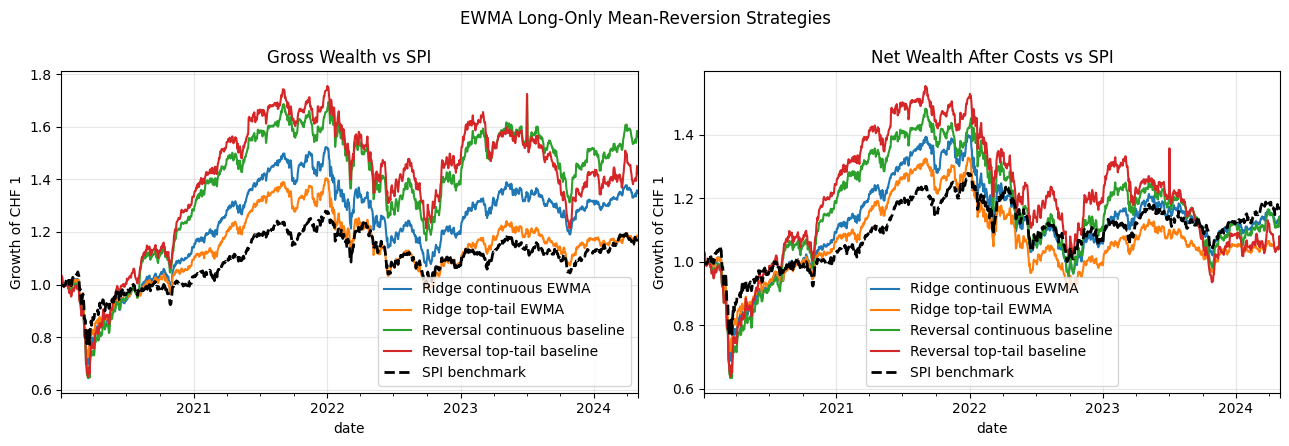

In [16]:
if CONFIG.run_ewma_strategies and strategy_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    benchmark_index = next(iter(strategy_results.values()))["net"].index
    spi_benchmark = spi_returns.reindex(benchmark_index).dropna()

    for name, result in strategy_results.items():
        (1 + result["gross"]).cumprod().plot(ax=axes[0], label=name, linewidth=1.5)
        (1 + result["net"]).cumprod().plot(ax=axes[1], label=name, linewidth=1.5)

    for ax in axes:
        (1 + spi_benchmark).cumprod().plot(
            ax=ax,
            label="SPI benchmark",
            color="black",
            linestyle="--",
            linewidth=2,
        )
        ax.set_ylabel("Growth of CHF 1")
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[0].set_title("Gross Wealth vs SPI")
    axes[1].set_title("Net Wealth After Costs vs SPI")
    fig.suptitle("EWMA Long-Only Mean-Reversion Strategies")
    fig.tight_layout()
    plt.show()
else:
    print("EWMA wealth plots skipped.")


## Ridge–Black-Litterman Strategy Backtest

Black-Litterman receives the same Ridge continuous and top-tail baskets used by the direct strategies. The Ridge model estimates relative attractiveness; BL determines a benchmark-aware, long-only allocation under budget, concentration and turnover-cost terms.

The view returns and variances are loaded from the 2010-2019 walk-forward calibration. They are not re-estimated from 2020+ outcomes.


In [17]:
def run_bl_strategy(target_weights: pd.DataFrame, view_return: float, view_variance: float) -> Strategy:
    """Run the constrained optimizer with one frozen Ridge basket view."""
    optimization_builders = {
        "return_series": OptimizationItemBuilder(
            bibfn=bibfn_return_series,
            width=CONFIG.lookback_days,
            weekdays_only=True,
            fillna_value=0,
        ),
        "cap_weights": OptimizationItemBuilder(bibfn=bibfn_cap_weights),
        "signal_weights": OptimizationItemBuilder(
            bibfn=CostAwareOneSidedBasketBlackLitterman.bibfn_signal_weights,
            target_weights=target_weights,
        ),
        "budget": OptimizationItemBuilder(bibfn=bibfn_budget_constraint, budget=1),
        "box": OptimizationItemBuilder(
            bibfn=bibfn_box_constraints,
            box_type="LongOnly",
            lower=0,
            upper=CONFIG.bl_stock_upper_bound,
        ),
    }
    if CONFIG.bl_use_hard_turnover_cap:
        optimization_builders["turnover"] = OptimizationItemBuilder(
            bibfn=bibfn_turnover_constraint,
            turnover_limit=CONFIG.bl_turnover_limit,
        )

    service = BacktestService(
        data=data,
        selection_item_builders=selection_builders,
        optimization_item_builders=optimization_builders,
        optimization=CostAwareOneSidedBasketBlackLitterman(
            tau=CONFIG.bl_tau,
            risk_aversion=CONFIG.bl_risk_aversion,
            view_return=view_return,
            view_variance=view_variance,
            turnover_penalty=CONFIG.bl_turnover_penalty,
            use_hard_turnover_cap=CONFIG.bl_use_hard_turnover_cap,
            hard_turnover_limit=CONFIG.bl_turnover_limit,
        ),
        rebdates=rebalance_date_strings,
        quiet=not CONFIG.show_backtest_progress,
    )
    backtest = Backtest()
    backtest.run(service)
    return backtest.strategy


if CONFIG.run_black_litterman_strategies:
    bl_strategies = {
        "Ridge-BL continuous view": run_bl_strategy(
            continuous_target_weights,
            float(ridge_calibration["bl_continuous_view_return"]),
            float(ridge_calibration["bl_continuous_view_variance"]),
        ),
        "Ridge-BL top-tail view": run_bl_strategy(
            tail_target_weights,
            float(ridge_calibration["bl_tail_view_return"]),
            float(ridge_calibration["bl_tail_view_variance"]),
        ),
    }
    bl_strategy_weights = {
        name: strategy.get_weights_df().set_index(
            pd.to_datetime(strategy.get_weights_df().index)
        )
        for name, strategy in bl_strategies.items()
    }
else:
    bl_strategies, bl_strategy_weights = {}, {}
    print("Black-Litterman backtests skipped.")


Running backtest: 100%|##########| 225/225 [13:32<00:00,  3.61s/it, 2024-04-19]


In [18]:
def average_signal_exposure(weights: pd.DataFrame, signal_weights: pd.DataFrame) -> float:
    """Average basket exposure w_t' w_signal,t across rebalance dates."""
    aligned_weights, aligned_signal = weights.align(signal_weights, join="outer", axis=1, fill_value=0.0)
    aligned_signal = aligned_signal.reindex(aligned_weights.index).fillna(0.0)
    return (aligned_weights.fillna(0.0) * aligned_signal).sum(axis=1).mean()


def hard_cap_binding_frequency(result: dict) -> float:
    """Approximate hard-cap binding frequency from realized portfolio turnover."""
    if not CONFIG.bl_use_hard_turnover_cap:
        return np.nan
    recurring_turnover = result["turnover"].iloc[1:]
    return np.isclose(recurring_turnover, CONFIG.bl_turnover_limit, atol=1e-4).mean()


if CONFIG.run_black_litterman_strategies:
    bl_strategy_results = {
        name: evaluate_strategy(strategy, return_series)
        for name, strategy in bl_strategies.items()
    }

    bl_reference_result = next(iter(bl_strategy_results.values()))
    bl_spi_summary = benchmark_summary(
        "SPI benchmark",
        spi_returns,
        bl_reference_result["net"].index,
        bl_reference_result["turnover"].index,
    )
    bl_performance_table = pd.DataFrame(
        [strategy_summary(name, result, spi_returns) for name, result in bl_strategy_results.items()]
        + [bl_spi_summary]
    )
    display(bl_performance_table.round(4))

    # Factor-model attribution is reported with the same helper used for EWMA strategies.
    bl_factor_diagnostics = factor_diagnostics_table(bl_strategy_results)
    display(bl_factor_diagnostics.round(4))

    bl_signal_baskets = {
        "Ridge-BL continuous view": continuous_target_weights,
        "Ridge-BL top-tail view": tail_target_weights,
    }
    bl_implementation_diagnostics = pd.DataFrame(
        [
            pd.Series(
                {
                    "Average signal exposure": average_signal_exposure(
                        bl_strategy_weights[name],
                        bl_signal_baskets[name],
                    ),
                    "Hard turnover cap binding frequency": hard_cap_binding_frequency(result),
                },
                name=name,
            )
            for name, result in bl_strategy_results.items()
        ]
    )
    display(bl_implementation_diagnostics.round(4))
else:
    bl_strategy_results = {}
    bl_performance_table = pd.DataFrame()
    bl_factor_diagnostics = pd.DataFrame()
    bl_implementation_diagnostics = pd.DataFrame()
    print("Black-Litterman metrics skipped.")


,Geometric annual return,Geometric annual excess return vs SPI,Annual volatility,Sharpe ratio,Skewness,Excess kurtosis,Maximum drawdown,Win rate,Average weekly turnover,Annual TC + 1% fee,Gross bps per trade,Observations
Ridge-BL continuous view,0.0096,-0.0251,0.1520,0.1388,0.0962,68.8391,-0.2695,0.5714,0.0179,0.0119,322.9279,"1,127.0000"
Ridge-BL top-tail view,0.0090,-0.0256,0.1525,0.1353,0.1695,72.4775,-0.2682,0.5714,0.0179,0.0119,315.4880,"1,127.0000"
SPI benchmark,0.0346,0.0000,0.1526,0.2997,-0.7894,11.7741,-0.2633,0.5848,NaN,NaN,NaN,"1,127.0000"


,Annualized alpha,Alpha p-value,Information ratio,IR t-statistic,Regression R-squared,Beta SPI,P-value SPI,Beta size,P-value size,Beta value,P-value value,Beta momentum,P-value momentum
Ridge-BL continuous view,-0.0075,0.8228,-0.0693,-0.2239,0.4993,0.7339,0.0000,0.0782,0.1310,0.0492,0.3457,-0.0480,0.2177
Ridge-BL top-tail view,-0.0081,0.8116,-0.0733,-0.2384,0.4883,0.7311,0.0000,0.0842,0.1063,0.0538,0.3068,-0.0457,0.2472


,Average signal exposure,Hard turnover cap binding frequency
Ridge-BL continuous view,0.0171,NaN
Ridge-BL top-tail view,0.0236,NaN


## Subperiod Results

The table reports net-of-cost metrics for the full out-of-sample period and for
fixed calendar subperiods. These descriptive windows show how performance varies
through time without affecting model selection, portfolio construction, or any
frozen parameter.


In [19]:
def fixed_period_summary(
    returns: pd.Series,
    start: Optional[str],
    end: Optional[str],
) -> pd.Series:
    """Compute a compact net-performance row for one pre-specified period."""
    sample = returns.sort_index()
    if start is not None:
        sample = sample.loc[sample.index >= pd.Timestamp(start)]
    if end is not None:
        sample = sample.loc[sample.index <= pd.Timestamp(end)]

    return pd.Series(
        {
            "Geometric annual return": geometric_annual_return(sample),
            "Annual volatility": annual_volatility(sample),
            "Sharpe ratio": sharpe_ratio(sample),
            "Maximum drawdown": max_drawdown(sample),
            "Observations": len(sample.dropna()),
        }
    )


all_strategy_results = {**strategy_results, **bl_strategy_results}
common_return_index = next(iter(all_strategy_results.values()))["net"].index
reporting_returns = {
    name: result["net"] for name, result in all_strategy_results.items()
}
reporting_returns["SPI benchmark"] = spi_returns.reindex(common_return_index).dropna()

# Calendar windows are fixed before inspecting the refreshed results.
subperiods = {
    "Full OOS sample": (None, None),
    "2020-2021": ("2020-01-01", "2021-12-31"),
    "2022-2023": ("2022-01-01", "2023-12-31"),
    "2024 onward": ("2024-01-01", None),
}
subperiod_performance = pd.concat(
    {
        period_name: pd.DataFrame(
            {
                strategy_name: fixed_period_summary(returns, start, end)
                for strategy_name, returns in reporting_returns.items()
            }
        ).T
        for period_name, (start, end) in subperiods.items()
    },
    names=["Period", "Strategy"],
)
display(subperiod_performance.round(4))


Geometric annual return  \
Period          Strategy                                                
Full OOS sample Ridge continuous EWMA                          0.0286   
                Ridge top-tail EWMA                            0.0119   
                Reversal continuous baseline                   0.0266   
                Reversal top-tail baseline                     0.0131   
                Ridge-BL continuous view                       0.0096   
                Ridge-BL top-tail view                         0.0090   
                SPI benchmark                                  0.0346   
2020-2021       Ridge continuous EWMA                          0.1748   
                Ridge top-tail EWMA                            0.1451   
                Reversal continuous baseline                   0.1857   
                Reversal top-tail baseline                     0.2234   
                Ridge-BL continuous view                       0.0562   
                Ridge-BL top-tail view                         0.0554   
                SPI benchmark                                  0.1232   
2022-2023       Ridge continuous EWMA                         -0.0998   
                Ridge top-tail EWMA                           -0.1047   
                Reversal continuous baseline                  -0.1092   
                Reversal top-tail baseline                    -0.1490   
                Ridge-BL continuous view                      -0.0490   
                Ridge-BL top-tail view                        -0.0491   
                SPI benchmark                                 -0.0569   
2024 onward     Ridge continuous EWMA                          0.0309   
                Ridge top-tail EWMA                            0.0035   
                Reversal continuous baseline                   0.0134   
                Reversal top-tail baseline                    -0.0698   
                Ridge-BL continuous view                       0.1018   
                Ridge-BL top-tail view                         0.0995   
                SPI benchmark                                  0.1017   

                                              Annual volatility  Sharpe ratio  \
Period          Strategy                                                        
Full OOS sample Ridge continuous EWMA                    0.1701        0.2513   
                Ridge top-tail EWMA                      0.1651        0.1543   
                Reversal continuous baseline             0.2035        0.2311   
                Reversal top-tail baseline               0.2147        0.1680   
                Ridge-BL continuous view                 0.1520        0.1388   
                Ridge-BL top-tail view                   0.1525        0.1353   
                SPI benchmark                            0.1526        0.2997   
2020-2021       Ridge continuous EWMA                    0.1872        0.9554   
                Ridge top-tail EWMA                      0.1834        0.8314   
                Reversal continuous baseline             0.2039        0.9384   
                Reversal top-tail baseline               0.2089        1.0704   
                Ridge-BL continuous view                 0.1406        0.4599   
                Ridge-BL top-tail view                   0.1401        0.4558   
                SPI benchmark                            0.1729        0.7592   
2022-2023       Ridge continuous EWMA                    0.1620       -0.5676   
                Ridge top-tail EWMA                      0.1554       -0.6335   
                Reversal continuous baseline             0.2130       -0.4367   
                Reversal top-tail baseline               0.2253       -0.6037   
                Ridge-BL continuous view                 0.1715       -0.2077   
                Ridge-BL top-tail view                   0.1729       -0.2052   
                SPI benchmark                            0.1386       -0.

## Black-Litterman Gross And Net Wealth

The BL wealth plots follow the same convention as the EWMA section. Gross wealth isolates the optimized signal tilt before costs; net wealth applies the configured transaction-cost simulation. SPI is the black dashed benchmark path.


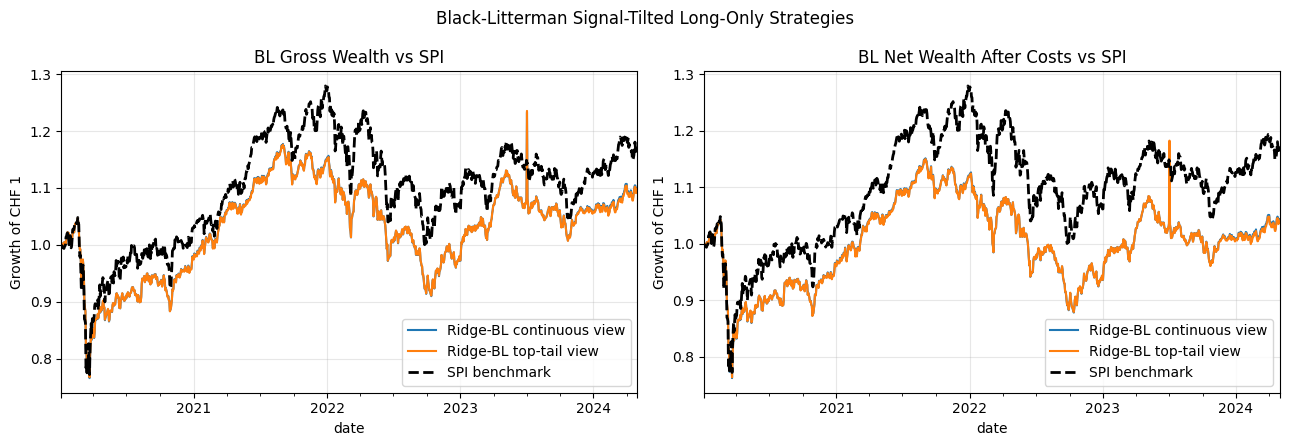

In [20]:
if CONFIG.run_black_litterman_strategies and bl_strategy_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    bl_benchmark_index = next(iter(bl_strategy_results.values()))["net"].index
    bl_spi_benchmark = spi_returns.reindex(bl_benchmark_index).dropna()

    for name, result in bl_strategy_results.items():
        (1 + result["gross"]).cumprod().plot(ax=axes[0], label=name, linewidth=1.5)
        (1 + result["net"]).cumprod().plot(ax=axes[1], label=name, linewidth=1.5)

    for ax in axes:
        (1 + bl_spi_benchmark).cumprod().plot(
            ax=ax,
            label="SPI benchmark",
            color="black",
            linestyle="--",
            linewidth=2,
        )
        ax.set_ylabel("Growth of CHF 1")
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[0].set_title("BL Gross Wealth vs SPI")
    axes[1].set_title("BL Net Wealth After Costs vs SPI")
    fig.suptitle("Black-Litterman Signal-Tilted Long-Only Strategies")
    fig.tight_layout()
    plt.show()
else:
    print("Black-Litterman wealth plots skipped.")


## Final Conclusion

### Main Result

The out-of-sample evidence provides qualified support for the Ridge-enhanced
mean-reversion strategy. The continuous Ridge-EWMA portfolio is the strongest
implementation: it earns a 2.86% annual net return, exceeds the comparable
reversal baseline, and reduces average weekly turnover from 63.08% to 28.49%.
However, it remains below the SPI's 3.46% annual return and does not produce
statistically significant alpha.

### Portfolio-Construction Evidence

- **Continuous Ridge-EWMA:** Ridge adds modest value across the broad stock
  ranking while EWMA materially improves implementation efficiency.
- **Top-tail Ridge-EWMA:** the concentrated basket is weaker, indicating that
  Ridge's predictive information is distributed across the ranking rather than
  concentrated only in its highest scores.
- **Black-Litterman:** both optimized portfolios keep average weekly turnover
  near 1.79% and remain benchmark-aware, but their approximately 0.9% annual net
  returns are lower than those of the direct EWMA strategies.

### Final Strategy Choice

The results do not establish superiority over a passive SPI investment.
Nevertheless, Ridge improves stock ranking and reduces the trading burden of the
original reversal strategy. The continuous Ridge-EWMA portfolio is therefore the
preferred implementation. Black-Litterman remains an optional allocation layer
for investors who prioritize benchmark alignment and very low turnover over
higher expected active returns.
